# FINA 4713 – Project Skeleton Code
**Introduction to AI and Big Data in Finance**

This notebook walks through a complete pipeline for cross-sectional return prediction:
preprocessing → model selection → expanding-window retraining → portfolio construction → evaluation.
Use it as a starting point. Replace or extend any step for your group's exploration direction.

| Split | Period |
|-------|--------|
| Training | Jan 2005 – Dec 2015 |
| Validation | Jan 2016 – Dec 2018 |
| Test | Jan 2019 – Dec 2024 |

## Setup

### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings; warnings.filterwarnings('ignore')

# PyTorch imports for PTK-SDF
import torch
import torch.nn as nn
import torch.optim as optim
from typing import List
import random
import os

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
try:
    from tqdm.auto import tqdm
except ImportError:
    print(ImportError)
    def tqdm(iterable, **kwargs): return iterable


In [ ]:
# Device detection — MPS on Apple Silicon, CUDA on NVIDIA, CPU otherwise
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')
if DEVICE.type == 'mps':
    print('  Apple Silicon GPU (MPS) — training will use Metal acceleration')
elif DEVICE.type == 'cuda':
    print(f'  NVIDIA GPU: {torch.cuda.get_device_name(0)}')
else:
    print('  No GPU found — falling back to CPU')


In [ ]:
class Config:
    """PTK-SDF Hyperparameters"""
    # DNN Architecture
    HIDDEN_DIM = 32              # Hidden layer size
    DNN_EPOCHS = 15              # Training epochs
    DNN_LEARNING_RATE = 1e-3    # Learning rate
    
    # PTK Pricing (Critical!)
    RIDGE_PENALTY = 1e-3     # Ridge penalty for PTK factors
    
    # Rolling Window
    ROLLING_WINDOW = 12          # Months for rolling training
    
    # Data filters
    MIN_STOCKS_PER_MONTH = 20
    MAX_TRAIN_SAMPLES = 100000
    PTK_TRAIN_SPLIT = 0.7        # For PTK pricing stage

ptk_cfg = Config()

In [3]:
class PTKNetwork(nn.Module):
    """Shallow neural network with 1 hidden layer"""
    def __init__(self, input_dim: int, hidden_dim: int):
        super(PTKNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)


def msrr_loss(predictions: torch.Tensor, returns: torch.Tensor) -> torch.Tensor:
    """Maximal Sharpe Ratio Regression loss"""
    portfolio_return = (predictions * returns).sum()
    loss = (1 - portfolio_return) ** 2
    return loss / len(returns)


def train_dnn(X_train: np.ndarray, R_train: np.ndarray, input_dim: int, cfg: Config) -> nn.Module:
    """Train DNN with MSRR loss on best available device."""
    model = PTKNetwork(input_dim, cfg.HIDDEN_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=cfg.DNN_LEARNING_RATE)

    X_t = torch.FloatTensor(X_train).to(DEVICE)
    R_t = torch.FloatTensor(R_train).to(DEVICE)

    for epoch in range(cfg.DNN_EPOCHS):
        model.train()
        optimizer.zero_grad()
        predictions = model(X_t)
        loss = msrr_loss(predictions, R_t)
        loss.backward()
        optimizer.step()

    return model.cpu()  # return CPU model for safe inference


def compute_ptk_gradients(model: nn.Module, X: np.ndarray, R: np.ndarray) -> np.ndarray:
    """Compute PTK gradient features (model expected on CPU)."""
    model.eval()
    X_t = torch.FloatTensor(X).requires_grad_(True)
    R_t = torch.FloatTensor(R)

    predictions = model(X_t)
    portfolio_return = (predictions * R_t).sum()

    gradients = torch.autograd.grad(
        outputs=portfolio_return,
        inputs=model.parameters(),
        create_graph=False,
        retain_graph=False
    )

    scaling = 1.0 / np.sqrt(len(R))
    grad_vector = torch.cat([g.flatten() for g in gradients])
    return (scaling * grad_vector).detach().numpy()


class PTK_Pricer:
    """Ridge regression pricing of PTK factors"""
    def __init__(self, ridge_penalty: float):
        self.ridge_penalty = ridge_penalty
        self.weights = None
        self.scaler = StandardScaler()

    def fit(self, F: np.ndarray):
        T, P = F.shape
        F_scaled = self.scaler.fit_transform(F)
        F_bar = F_scaled.mean(axis=0)
        covariance = (F_scaled.T @ F_scaled) / T
        zI = self.ridge_penalty * np.eye(P)
        try:
            inv_matrix = np.linalg.inv(zI + covariance)
            self.weights = inv_matrix @ F_bar
        except np.linalg.LinAlgError:
            self.weights = np.linalg.pinv(zI + covariance) @ F_bar
        return self

    def predict(self, F_new: np.ndarray) -> float:
        F_new_scaled = self.scaler.transform(F_new.reshape(1, -1))
        return (F_new_scaled @ self.weights)[0]


In [4]:
def preprocess_data_paper_style(df: pd.DataFrame, features: List[str], verbose=True):
    """Paper's preprocessing: rank-standardize + median imputation"""
    
    df_processed = df.copy()
    
    # Filter characteristics with <30% missing
    missing_pct = df_processed[features].isna().mean()
    keep_chars = missing_pct[missing_pct < 0.30].index.tolist()
    
    if verbose:
        print(f"  Features: {len(features)} → {len(keep_chars)} (<30% missing)")
    features = keep_chars
    
    # Rank-standardize each characteristic to [-0.5, 0.5]
    for char in features:
        for month in df_processed['eom'].unique():
            month_mask = df_processed['eom'] == month
            values = df_processed.loc[month_mask, char].values
            if len(values) > 0:
                rank = np.argsort(np.argsort(values))
                if len(rank) > 1:
                    normalized = (rank / (len(rank) - 1) - 0.5)
                else:
                    normalized = np.zeros_like(rank)
                df_processed.loc[month_mask, char] = normalized
    
    # Impute with cross-sectional median
    for month in df_processed['eom'].unique():
        month_mask = df_processed['eom'] == month
        for char in features:
            median_val = df_processed.loc[month_mask, char].median()
            if pd.isna(median_val):
                median_val = df_processed[char].median()
            df_processed.loc[month_mask, char] = df_processed.loc[month_mask, char].fillna(median_val)
    
    return df_processed, features

## 1. Load Data

### Load and inspect

In [ ]:
df = pd.read_parquet('jkp_data.parquet')
print(f"Shape : {df.shape}")
print(f"Period: {df['eom'].min().date()} to {df['eom'].max().date()}")
print(f"Firms : {df['id'].nunique():,}")
print(f"\nColumns:\n{df.columns.tolist()}")

Shape : (3096206, 201)
Period: 2005-01-31 to 2024-12-31
Firms : 38,009

Columns:
['id', 'eom', 'excntry', 'ret_exc_lead1m', 'me', 'be_me', 'at_me', 'sale_me', 'ni_me', 'ocf_me', 'fcf_me', 'ebitda_mev', 'bev_mev', 'eq_dur', 'ival_me', 'netdebt_me', 'rd_me', 'debt_me', 'div12m_me', 'eqpo_me', 'eqnpo_me', 'gp_at', 'ope_be', 'ni_be', 'cop_at', 'op_at', 'ocf_at', 'ebit_sale', 'gp_atl1', 'ope_bel1', 'cop_atl1', 'niq_be', 'niq_at', 'pi_nix', 'op_atl1', 'ocf_at_chg1', 'niq_be_chg1', 'ret_1_0', 'ret_2_0', 'ret_3_0', 'ret_3_1', 'ret_6_0', 'ret_6_1', 'ret_9_0', 'ret_9_1', 'ret_12_0', 'ret_12_1', 'ret_12_7', 'ret_60_12', 'ret_18_1', 'ret_24_1', 'ret_24_12', 'ret_36_1', 'ret_36_12', 'ret_48_1', 'ret_60_1', 'ret_60_36', 'resff3_12_1', 'resff3_6_1', 'seas_1_1an', 'seas_1_1na', 'seas_2_5an', 'seas_2_5na', 'seas_6_10an', 'seas_6_10na', 'seas_11_15an', 'seas_11_15na', 'seas_16_20an', 'seas_16_20na', 'at_gr1', 'sale_gr1', 'capx_gr1', 'inv_gr1', 'noa_gr1a', 'ppeinv_gr1a', 'lnoa_gr1a', 'debt_gr3', 'sale_gr

In [6]:
def set_all_seeds(seed: int = 42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_all_seeds(42)


## 2. Feature Selection and Train/Val/Test Split

### Define features, log-transform size, split by date

In [7]:
TARGET = 'ret_exc_lead1m'

# Log-transform size: market equity is right-skewed
df['log_me'] = np.log1p(df['me'].clip(lower=0))

# Use all numeric characteristics in the slim file (plus log_me)
META     = ['id', 'eom', 'excntry', TARGET, 'me']
FEATURES = [c for c in df.columns if c not in META] + ['log_me']

# Drop rows with missing target (these cannot be used for training or evaluation)
df = df.dropna(subset=[TARGET])

# Temporal splits — do not change these dates; they are uniform across all groups
TRAIN_END = '2015-12-31'
VAL_END   = '2018-12-31'

train = df[df['eom'] <= TRAIN_END]
val   = df[(df['eom'] > TRAIN_END) & (df['eom'] <= VAL_END)]
test  = df[df['eom'] > VAL_END]

print(f"Train : {len(train):>7,} obs  ({train['eom'].min().date()} – {train['eom'].max().date()})")
print(f"Val   : {len(val):>7,} obs  ({val['eom'].min().date()} – {val['eom'].max().date()})")
print(f"Test  : {len(test):>7,} obs  ({test['eom'].min().date()} – {test['eom'].max().date()})")
print(f"Features: {len(FEATURES)}")

Train : 1,570,926 obs  (2005-01-31 – 2015-12-31)
Val   : 458,210 obs  (2016-01-31 – 2018-12-31)
Test  : 973,847 obs  (2019-01-31 – 2024-11-30)
Features: 198


In [ ]:
# ── Step 2.5: Selective log-transform (skewness computed on training data only) ──
# sign(x)*log1p(|x|) is monotone → Spearman IC is invariant. Benefits: better
# winsorisation quantiles and smoother inputs for NN training.
SKEW_THRESHOLD = 1.0

def apply_signed_log1p(df_split, log_feats):
    """Apply sign(x)*log1p(|x|) to specified features."""
    df_out = df_split.copy()
    for f in log_feats:
        if f in df_out.columns:
            s = pd.to_numeric(df_out[f], errors='coerce')
            df_out[f] = np.sign(s) * np.log1p(np.abs(s))
    return df_out

# Compute skewness on training data ONLY (no look-ahead)
_train_for_skew = df[df['eom'] <= TRAIN_END]
train_skew = _train_for_skew[FEATURES].apply(pd.to_numeric, errors='coerce').skew()
LOG_FEATURES = train_skew[train_skew.abs() > SKEW_THRESHOLD].index.tolist()
n_log = len(LOG_FEATURES)

print(f"Selective log-transform: {n_log}/{len(FEATURES)} features transformed (|skew| > {SKEW_THRESHOLD})")

# Apply to df so that the expanding-window loop also uses transformed data
df = apply_signed_log1p(df, LOG_FEATURES)
train = df[df['eom'] <= TRAIN_END]
val   = df[(df['eom'] > TRAIN_END) & (df['eom'] <= VAL_END)]
test  = df[df['eom'] > VAL_END]
print(f"  Re-sliced train/val/test from log-transformed df")


In [ ]:
# ── Step 3: IC Screening (Spearman rank IC, training period only) ───────────
IC_THRESHOLD = 1.5   # |IC t-stat| cutoff

def compute_ic_matrix(df_split, feats):
    """Monthly cross-sectional Spearman IC for each feature vs. next-month return."""
    rows = []
    for _, grp in df_split.groupby('eom'):
        y = pd.to_numeric(grp[TARGET], errors='coerce')
        row = []
        for f in feats:
            x = pd.to_numeric(grp[f], errors='coerce')
            valid = x.notna() & y.notna()
            row.append(spearmanr(x[valid], y[valid])[0] if valid.sum() >= 50 else np.nan)
        rows.append(row)
    return pd.DataFrame(rows, columns=feats)

print("Computing monthly Spearman IC on training data (may take a few minutes)...")
ic_mat  = compute_ic_matrix(train, FEATURES)
mean_ic = ic_mat.mean()
std_ic  = ic_mat.std()
T_ic    = ic_mat.notna().sum()
ic_tstat = mean_ic / std_ic * np.sqrt(T_ic)

IC_FEATURES = ic_tstat[ic_tstat.abs() >= IC_THRESHOLD].index.tolist()
n_keep = len(IC_FEATURES)
n_drop = len(FEATURES) - n_keep
print(f"IC Screening: {len(FEATURES)} → {n_keep} kept, {n_drop} dropped  (|t| ≥ {IC_THRESHOLD})")


## 3. Preprocessing Pipeline

**No look-ahead:** winsorisation bounds, imputer medians, and scaler statistics
are computed on the **training set only** and then applied unchanged to validation and test.
In the expanding-window retraining step (Section 6), these objects are re-fit on each
expanded training window — still using only data available up to that point.

### Fit on training data; apply to val/test with the same parameters

In [8]:
def fit_preprocessor(X_df):
    """Fit winsorisation bounds, median imputer, and z-score scaler on X_df."""
    low  = X_df.quantile(0.01)
    high = X_df.quantile(0.99)
    X_clipped = X_df.clip(lower=low, upper=high, axis=1)
    imp = SimpleImputer(strategy='median').fit(X_clipped)
    sc  = StandardScaler().fit(imp.transform(X_clipped))
    return low, high, imp, sc

def apply_preprocessor(X_df, low, high, imp, sc):
    """Apply pre-fitted preprocessor — no parameters are re-estimated here."""
    X = X_df.clip(lower=low, upper=high, axis=1)
    X = imp.transform(X)
    return sc.transform(X)

# Numeric helpers
to_num    = lambda df_: df_[FEATURES].apply(pd.to_numeric, errors='coerce')
to_num_ic = lambda df_: df_[IC_FEATURES].apply(pd.to_numeric, errors='coerce')

# ── FEATURE_GROUPS: 13 JKP economic themes + other (14 groups total) ─────────
FEATURE_GROUPS = {
    'momentum': [
        'ret_2_0', 'ret_3_0', 'ret_3_1', 'ret_6_0', 'ret_6_1',
        'ret_9_0', 'ret_9_1', 'ret_12_0', 'ret_12_1', 'ret_12_7',
        'ret_18_1', 'ret_24_1', 'ret_24_12', 'ret_36_1', 'ret_36_12',
        'ret_48_1', 'ret_48_12', 'ret_60_1', 'ret_60_12', 'ret_60_36',
        'resff3_6_1', 'resff3_12_1',
    ],
    'short_term_reversal': ['ret_1_0'],
    'seasonality': [
        'seas_1_1an', 'seas_1_1na', 'seas_2_5an', 'seas_2_5na',
        'seas_6_10an', 'seas_6_10na',
    ],
    'value': [
        'be_me', 'at_me', 'sale_me', 'ni_me', 'ocf_me', 'fcf_me',
        'ebitda_mev', 'bev_mev', 'eq_dur', 'ival_me', 'div12m_me',
        'eqpo_me', 'eqnpo_me', 'ebit_bev', 'cash_me', 'netis_mev', 'log_me',
    ],
    'profitability': [
        'gp_at', 'ope_be', 'ni_be', 'cop_at', 'op_at', 'ocf_at',
        'ebit_sale', 'gp_atl1', 'ope_bel1', 'cop_atl1', 'niq_be',
        'niq_at', 'pi_nix', 'op_atl1', 'ocf_at_chg1', 'niq_be_chg1',
    ],
    'profit_growth': [
        'gpoa_ch5', 'roe_ch5', 'roa_ch5', 'cfoa_ch5', 'gmar_ch5',
        'niq_su', 'ocfq_saleq_std', 'niq_saleq_std', 'roe_be_std',
        'dsale_dinv', 'dsale_drec', 'dgp_dsale', 'dsale_dsga',
        'ni_inc8q', 'niq_at_chg1',
    ],
    'investment': [
        'at_gr1', 'sale_gr1', 'capx_gr1', 'inv_gr1', 'noa_gr1a',
        'ppeinv_gr1a', 'lnoa_gr1a', 'sale_gr3', 'capx_gr3', 'capx_gr2',
        'inv_gr1a', 'be_gr1a', 'emp_gr1', 'saleq_gr1', 'capex_abn',
        'sti_gr1a', 'capx_gr3a', 'lti_gr1a',
    ],
    'accruals': [
        'oaccruals_at', 'taccruals_at', 'oaccruals_ni', 'taccruals_ni',
        'cowc_gr1a', 'ncoa_gr1a', 'ncol_gr1a', 'nncoa_gr1a',
        'coa_gr1a', 'col_gr1a', 'tax_gr1a', 'nfna_gr1a', 'fnl_gr1a', 'noa_at',
    ],
    'debt_issuance': [
        'chcsho_12m', 'eqnpo_12m', 'netis_at', 'eqnetis_at', 'dbnetis_at',
        'eqnpo_1m', 'eqnpo_3m', 'eqnpo_6m', 'div3m_me', 'div6m_me',
        'chcsho_1m', 'chcsho_3m', 'chcsho_6m', 'debt_gr3',
    ],
    'leverage': ['at_be', 'debt_me', 'netdebt_me', 'at_turnover', 'sale_bev', 'opex_at'],
    'low_risk': [
        'beta_60m', 'ivol_capm_21d', 'ivol_ff3_21d', 'ivol_capm_252d',
        'ivol_capm_60m', 'rvol_21d', 'rvol_252d', 'rmax1_21d', 'rmax5_21d',
        'betabab_1260d', 'coskew_21d', 'betadown_252d', 'iskew_capm_21d',
        'iskew_ff3_21d', 'iskew_hxz4_21d', 'ivol_hxz4_21d', 'beta_21d',
        'beta_252d', 'rmax5_rvol_21d', 'corr_1260d', 'beta_dimson_21d',
        'rvolhl_21d', 'rskew_21d',
    ],
    'quality': [
        'qmj', 'qmj_prof', 'qmj_growth', 'qmj_safety', 'f_score',
        'o_score', 'z_score', 'kz_index', 'ni_ar1', 'ni_ivol',
        'earnings_variability', 'tangibility', 'aliq_at', 'aliq_mat',
        'mispricing_mgmt', 'mispricing_perf',
    ],
    'size_liquidity': [
        'dolvol', 'dolvol_126d', 'dolvol_var_126d', 'turnover_126d',
        'turnover_var_126d', 'zero_trades_21d', 'zero_trades_126d',
        'zero_trades_252d', 'ami_126d', 'bidaskhl_21d', 'prc_highprc_252d',
        'bidask', 'tvol',
    ],
    'other': ['cash_at', 'age', 'sale_emp', 'sale_emp_gr1'],
}

# ── GroupedPCA: independent PCA within each JKP economic theme ───────────────
class GroupedPCA:
    """Fits independent PCA within each economic group (90% variance per group)."""
    def __init__(self, groups, var_threshold=0.90):
        self.groups = groups
        self.var_threshold = var_threshold
        self.fitted = {}       # {group: (features_used, pca_or_None)}
        self.output_names = [] # e.g. ['momentum_PC1', ..., 'value_PC1', ...]

    def fit(self, X_df):
        self.fitted = {}; self.output_names = []
        for grp, feats in self.groups.items():
            avail = [f for f in feats if f in X_df.columns]
            if len(avail) == 0:
                continue
            if len(avail) == 1:
                self.fitted[grp] = (avail, None)
                self.output_names.append(f'{grp}_F1')
                continue
            Xg = X_df[avail].values
            pca_full = PCA(n_components=min(len(avail), Xg.shape[0]-1)).fit(Xg)
            cumvar = np.cumsum(pca_full.explained_variance_ratio_)
            n_comp = int(np.searchsorted(cumvar, self.var_threshold)) + 1
            n_comp = max(1, min(n_comp, len(avail)))
            pca = PCA(n_components=n_comp).fit(Xg)
            self.fitted[grp] = (avail, pca)
            for i in range(n_comp):
                self.output_names.append(f'{grp}_PC{i+1}')
        return self

    def transform(self, X_df):
        parts = []
        for grp, (feats, pca) in self.fitted.items():
            avail = [f for f in feats if f in X_df.columns]
            Xg = X_df[avail].values if avail else np.zeros((len(X_df), len(feats)))
            parts.append(Xg if pca is None else pca.transform(Xg))
        return np.hstack(parts) if parts else np.zeros((len(X_df), 0))

    def fit_transform(self, X_df):
        return self.fit(X_df).transform(X_df)

# ── Preprocessing on IC-selected features (fit on training only) ─────────────
low_ic, high_ic, imp_ic, sc_ic = fit_preprocessor(to_num_ic(train))

X_tr_ic  = apply_preprocessor(to_num_ic(train), low_ic, high_ic, imp_ic, sc_ic)
X_val_ic = apply_preprocessor(to_num_ic(val),   low_ic, high_ic, imp_ic, sc_ic)
X_te_ic  = apply_preprocessor(to_num_ic(test),  low_ic, high_ic, imp_ic, sc_ic)

X_tr_ic_df  = pd.DataFrame(X_tr_ic,  columns=IC_FEATURES)
X_val_ic_df = pd.DataFrame(X_val_ic, columns=IC_FEATURES)
X_te_ic_df  = pd.DataFrame(X_te_ic,  columns=IC_FEATURES)

# ── Fit GroupedPCA on training only ──────────────────────────────────────────
gpca = GroupedPCA(FEATURE_GROUPS, var_threshold=0.90)
X_tr_pca  = gpca.fit_transform(X_tr_ic_df)
X_val_pca = gpca.transform(X_val_ic_df)
X_te_pca  = gpca.transform(X_te_ic_df)

# ── Main feature matrices: all models use IC+PCA components ──────────────────
X_tr  = X_tr_pca
X_val = X_val_pca
X_te  = X_te_pca

y_tr  = train[TARGET].values
y_val = val[TARGET].values
y_te  = test[TARGET].values

print(f"X_train : {X_tr.shape}  ({X_tr.shape[1]} PCA components from {len(IC_FEATURES)} IC features)")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_te.shape}")


X_train : (1570926, 198)
X_val   : (458210, 198)
X_test  : (973847, 198)


## 4. Baselines

### Historical-average benchmark — R² = 0 by construction

Predict every stock's return as the training-period mean.
We use the **Campbell & Thompson (2008) OOS R²** definition:

$$R^2_{OOS} = 1 - \frac{\text{MSE}_{\text{model}}}{\text{MSE}_{\text{hist avg}}}$$

Under this definition the historical-average model scores exactly **0.0** by construction.
Positive values mean the model beats the null; negative values mean it is worse.

In [9]:
def oos_r2(y_true, y_pred, y_null):
    """OOS R² relative to the historical-average null (Campbell & Thompson 2008)."""
    return 1 - np.mean((y_true - y_pred)**2) / np.mean((y_true - y_null)**2)

hist_avg    = y_tr.mean()                       # scalar: training-period mean return
y_null_val  = np.full(len(y_val), hist_avg)
y_null_te   = np.full(len(y_te),  hist_avg)

print(f"Training mean return: {hist_avg:.5f}")
print(f"Historical-average  val R²: {oos_r2(y_val, y_null_val, y_null_val):+.4f}  (always 0.0)")
print(f"Historical-average test R²: {oos_r2(y_te,  y_null_te,  y_null_te):+.4f}  (always 0.0)")

Training mean return: 0.00441
Historical-average  val R²: +0.0000  (always 0.0)
Historical-average test R²: +0.0000  (always 0.0)


### Market portfolio benchmark

Equal-weighted return of all stocks in the cross-section each month.
This is a long-only benchmark; it will be computed alongside the Ridge portfolio in Section 7.

## 4b. Portfolio Construction Helpers

These helpers are needed for Sharpe-based hyperparameter tuning in Section 5.
They are also used in the full portfolio evaluation in Section 7.

`portfolio_weights` converts raw predictions into dollar-neutral long–short weights using ranks.
`compute_portfolio_metrics` builds a monthly return series from those weights and returns
annualised return, vol, and Sharpe.

In [10]:
def portfolio_weights(pred, max_w=0.05):
    """Rank-based dollar-neutral long–short weights, capped at max_w per stock."""
    n  = len(pred)
    w  = pd.Series(pred).rank() - (n + 1) / 2   # centred ranks
    w /= w.abs().sum()                            # normalise
    w  = w.clip(-max_w, max_w)                   # cap concentration
    w /= w.abs().sum()                            # re-normalise after cap
    return w.values

def compute_portfolio_metrics(df_eval, pred_col, target_col='ret_exc_lead1m', date_col='eom'):
    """Build monthly long–short returns and return (ann_ret, ann_vol, sharpe)."""
    monthly_returns = []
    for _, grp in df_eval.groupby(date_col):
        w = portfolio_weights(grp[pred_col].values)
        monthly_returns.append((w * grp[target_col].values).sum())
    pf = pd.Series(monthly_returns)
    ann_ret = pf.mean() * 12
    ann_vol = pf.std() * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0.0
    return ann_ret, ann_vol, sharpe

In [11]:
# Use this (or other variations) if you want to enforce zero net investment

# def portfolio_weights(pred, max_w=0.05):
#     s = pd.Series(pred).rank(method='average') - (len(pred) + 1) / 2
#     w = s.to_numpy(dtype=float)

#     # scale raw signal
#     long = np.clip(w, 0, None)
#     short = np.clip(-w, 0, None)
#     if long.sum() == 0 or short.sum() == 0:
#         return np.zeros_like(w)
#     w = 0.5 * long / long.sum() - 0.5 * short / short.sum()

#     # optional cap
#     w = np.clip(w, -max_w, max_w)

#     # re-enforce 50/50 long-short after cap
#     long = np.clip(w, 0, None)
#     short = np.clip(-w, 0, None)
#     if long.sum() == 0 or short.sum() == 0:
#         return np.zeros_like(w)
#     return 0.5 * long / long.sum() - 0.5 * short / short.sum()

## 5. Ridge Regression

### Hyperparameter tuning on the validation set

Search over a log-spaced grid of the regularisation parameter α.
The best α is the one maximising the **validation-set Sharpe ratio** of the long–short portfolio.
The test set is **not touched** at this stage.

In [12]:
alpha_grid = [1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8]

print(f"{'Alpha':>10} | {'Val Sharpe':>10} | {'Val Ann. Ret':>12}")
print("-" * 38)

val_metrics = {}
val_eval = val[['eom', TARGET]].copy()

for alpha in alpha_grid:
    m = Ridge(alpha=alpha).fit(X_tr, y_tr)
    val_eval['ridge_pred'] = m.predict(X_val)
    ann_ret, ann_vol, sharpe = compute_portfolio_metrics(val_eval, 'ridge_pred', TARGET, 'eom')
    val_metrics[alpha] = sharpe
    print(f"{alpha:>10.0f} | {sharpe:>10.4f} | {ann_ret:>12.2%}")

best_alpha = max(val_metrics, key=val_metrics.get)
print(f"\n-> Best α = {best_alpha:.0f}  (val Sharpe = {val_metrics[best_alpha]:.4f})")

     Alpha | Val Sharpe | Val Ann. Ret
--------------------------------------
       100 |     1.2176 |        3.99%
      1000 |     1.2230 |        4.00%
     10000 |     1.2571 |        4.06%
    100000 |     1.2891 |        4.04%
   1000000 |     1.2652 |        4.00%
  10000000 |     1.3562 |        4.32%
 100000000 |     1.3315 |        4.37%

-> Best α = 10000000  (val Sharpe = 1.3562)


### Validation-set evaluation with best α

Confirm performance on the validation set before moving to the expanding-window step.

In [13]:
ridge_val = Ridge(alpha=best_alpha).fit(X_tr, y_tr)
print(f"Ridge (α={best_alpha:.0f})")
print(f"  Val  R²: {oos_r2(y_val, ridge_val.predict(X_val), y_null_val):+.4f}")
print(f"  Test R²: {oos_r2(y_te,  ridge_val.predict(X_te),  y_null_te):+.4f}  ← peek for reference only")

Ridge (α=10000000)
  Val  R²: +0.0010
  Test R²: +0.0003  ← peek for reference only


## 6. Expanding-Window Retraining

A static model trained on 2005–2015 ignores six years of new data by the time it predicts 2024 returns.
The expanding window fixes this: every January we refit the **preprocessor and model coefficients**
on all data available up to that point.

The hyperparameter α is **not re-tuned** — it is fixed at the value selected in Section 5.
Re-tuning at each step would require a fresh inner validation window and adds substantial complexity;
for this project, fixed α is the standard and defensible choice.

### Retrain annually; collect test-period predictions

In [14]:
records = []   # will collect one row per (stock, month) in the test period

for year in tqdm(range(2019, 2025), desc="Walk-Forward Years"):
    train_cut  = pd.Timestamp(f'{year}-01-01')
    test_start = pd.Timestamp(f'{year}-01-01')
    test_end   = pd.Timestamp(f'{year + 1}-01-01')

    df_tr = df[df['eom'] < train_cut]
    df_te = df[(df['eom'] >= test_start) & (df['eom'] < test_end)].dropna(subset=[TARGET])
    if df_te.empty:
        continue

    # Re-fit preprocessor on IC-selected features (expanding window, no look-ahead)
    lo, hi, imp_r, sc_r = fit_preprocessor(to_num_ic(df_tr))
    Xtr_ic = apply_preprocessor(to_num_ic(df_tr), lo, hi, imp_r, sc_r)
    Xte_ic = apply_preprocessor(to_num_ic(df_te), lo, hi, imp_r, sc_r)

    # Apply fixed PCA (eigenvectors from initial training period — no look-ahead)
    Xtr = gpca.transform(pd.DataFrame(Xtr_ic, columns=IC_FEATURES))
    Xte = gpca.transform(pd.DataFrame(Xte_ic, columns=IC_FEATURES))
    ytr = df_tr[TARGET].values

    # Refit Ridge with fixed α on expanded training set
    ridge = Ridge(alpha=best_alpha).fit(Xtr, ytr)

    tmp = df_te[['eom', TARGET]].copy().reset_index(drop=True)
    tmp['ridge_pred'] = ridge.predict(Xte)
    tmp['hist_avg']   = ytr.mean()          # expanding training mean at this update
    records.append(tmp)

    print(f"  {year}: train {len(df_tr):>7,} obs  →  test {len(df_te):>6,} obs")

results = pd.concat(records, ignore_index=True)
print(f"\nTotal test observations: {len(results):,}")


Walk-Forward Years:   0%|          | 0/6 [00:00<?, ?it/s]

  2019: train 2,029,136 obs  →  test 159,831 obs
  2020: train 2,188,967 obs  →  test 168,255 obs
  2021: train 2,357,222 obs  →  test 150,624 obs
  2022: train 2,507,846 obs  →  test 162,275 obs
  2023: train 2,670,121 obs  →  test 176,725 obs
  2024: train 2,846,846 obs  →  test 156,137 obs

Total test observations: 973,847


## 7. Portfolio Construction

### Rank-based zero-cost long–short weights

Raw predicted returns can be extreme outliers. Replacing predictions with their cross-sectional rank
makes weights robust: the highest-ranked stock gets the same fixed overweight regardless of
whether its predicted return is 5% or 500%.  Steps:

1. Rank stocks within each month-cross-section.
2. Centre ranks → the portfolio is zero-cost (long leg ≈ short leg).
3. Normalise so |long| = |short| = 0.5.
4. Hard-cap at `max_w` per stock (rarely binds in large cross-sections).

In [15]:
def portfolio_weights(pred, max_w=0.05):
    n   = len(pred)
    w   = pd.Series(pred).rank() - (n + 1) / 2   # centred ranks
    w  /= w.abs().sum()                            # normalise
    w   = w.clip(-max_w, max_w)                    # cap
    w  /= w.abs().sum()                            # re-normalise after cap
    return w.values

monthly = []
for eom_date, grp in results.groupby('eom'):
    ret_xs = grp[TARGET].values
    monthly.append({
        'date'   : eom_date,
        'Ridge'  : (portfolio_weights(grp['ridge_pred'].values) * ret_xs).sum(),
        'HistAvg': 0.0,              # no signal → zero long–short return (exact by construction)
        'Market' : ret_xs.mean(),    # equal-weighted long-only benchmark
    })



In [16]:
pf = pd.DataFrame(monthly).set_index('date').sort_index()
pf.index = pd.to_datetime(pf.index)
print(f"Monthly portfolio returns: {len(pf)} months")

Monthly portfolio returns: 71 months


## 8. Evaluation

### Out-of-sample R² and Information Coefficient (IC)

**OOS R²** (Campbell-Thompson): measures whether the model's predictions reduce MSE relative to
the historical average.  Values are typically small — even +0.5% is economically meaningful
for monthly returns.

**IC**: cross-sectional Spearman rank correlation between predicted and realised returns,
computed each month and averaged.  Measures ordinal predictability; positive IC means
high-predicted stocks tend to realise higher returns.

In [17]:
y_true = results[TARGET].values
y_null = results['hist_avg'].values

# OOS R²
print("OOS R² (Campbell-Thompson, test 2019–2024)")
print(f"  Historical average : {oos_r2(y_true, y_null,                        y_null):+.4f}  (always 0.0)")
print(f"  Ridge              : {oos_r2(y_true, results['ridge_pred'].values,   y_null):+.4f}")

# Monthly IC
ic_ridge = results.groupby('eom').apply(
    lambda g: spearmanr(g['ridge_pred'], g[TARGET])[0]
)
t_stat = ic_ridge.mean() / ic_ridge.std() * np.sqrt(len(ic_ridge))

print(f"\nIC (cross-sectional Spearman ρ, monthly)")
print(f"  Ridge  mean IC : {ic_ridge.mean():+.4f}")
print(f"  Ridge  IC t-stat: {t_stat:+.2f}  ({len(ic_ridge)} months)")

OOS R² (Campbell-Thompson, test 2019–2024)
  Historical average : +0.0000  (always 0.0)
  Ridge              : +0.0001

IC (cross-sectional Spearman ρ, monthly)
  Ridge  mean IC : +0.0367
  Ridge  IC t-stat: +4.16  (71 months)


### Sharpe ratio and portfolio summary

In [18]:
ann_ret = pf.mean() * 12
ann_vol = pf.std()  * np.sqrt(12)
sharpe  = ann_ret / ann_vol

print(f"Portfolio Performance (annualised, test period 2019–2024)")
print(f"{'Model':<12} {'Ann. Return':>12} {'Ann. Vol':>10} {'Sharpe':>8}")
print("-" * 46)
for m in ['HistAvg', 'Ridge', 'Market']:
    print(f"{m:<12} {ann_ret[m]:>12.2%} {ann_vol[m]:>10.2%} {sharpe[m]:>8.2f}")
print()
print("Note: HistAvg long–short return is identically 0 (no signal → uniform weights = flat).")
print("      Market is long-only; Ridge is zero-cost — volatilities are not directly comparable.")

Portfolio Performance (annualised, test period 2019–2024)
Model         Ann. Return   Ann. Vol   Sharpe
----------------------------------------------
HistAvg             0.00%      0.00%      nan
Ridge               4.43%      4.39%     1.01
Market              5.88%     18.96%     0.31

Note: HistAvg long–short return is identically 0 (no signal → uniform weights = flat).
      Market is long-only; Ridge is zero-cost — volatilities are not directly comparable.


### Cumulative return plot

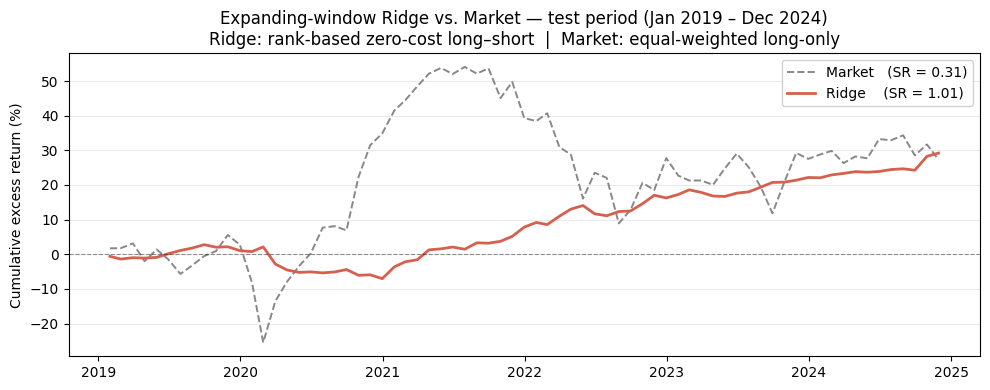

In [19]:
cum = (1 + pf).cumprod() - 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cum.index, cum['Market'] * 100,
        color='#888888', linestyle='--', lw=1.4,
        label=f"Market   (SR = {sharpe['Market']:.2f})")
ax.plot(cum.index, cum['Ridge'] * 100,
        color='#d6604d', lw=2.0,
        label=f"Ridge    (SR = {sharpe['Ridge']:.2f})")
ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylabel('Cumulative excess return (%)')
ax.set_title(
    'Expanding-window Ridge vs. Market — test period (Jan 2019 – Dec 2024)\n'
    'Ridge: rank-based zero-cost long–short  |  Market: equal-weighted long-only'
)
ax.legend(framealpha=0.9)
ax.grid(axis='y', lw=0.4, alpha=0.5)
fig.tight_layout()
plt.show()

## 9. Feature Importance (Economic Reasoning)

The largest Ridge coefficients from the **final** walk-forward step (model trained through 2023,
predicting 2024 returns) indicate which characteristics drive the model's predictions most.
Positive coefficients → the model expects higher returns from stocks with high values of that
characteristic; negative → lower returns.

**Caveat:** coefficients reflect only the last retraining step and are on standardised features,
so they measure relative importance within the model, not causal effects on stock returns.

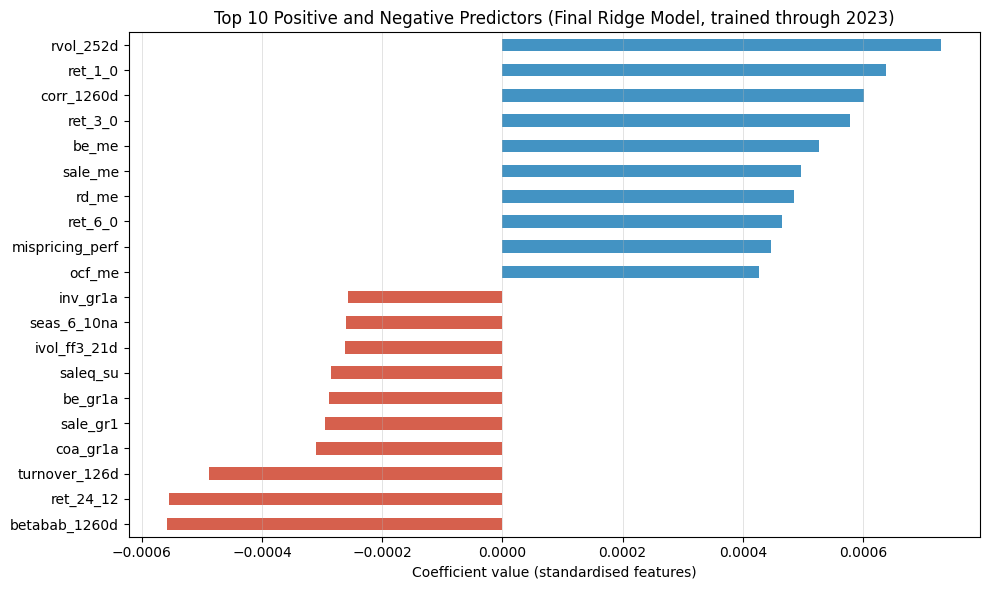

In [20]:
coefs = pd.Series(ridge.coef_, index=gpca.output_names)
top_pos = coefs.nlargest(10)
top_neg = coefs.nsmallest(10)
top_features = pd.concat([top_pos, top_neg]).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d6604d' if c < 0 else '#4393c3' for c in top_features.values]
top_features.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Top 10 Positive and Negative Predictors (Final Ridge Model, trained through 2023)')
ax.set_xlabel('Coefficient value (standardised features)')
ax.grid(axis='x', lw=0.5, alpha=0.5)
fig.tight_layout()
plt.show()

In [21]:
from sklearn.linear_model import LinearRegression

# Use the already preprocessed data from Ridge
X_tr_base = X_tr
X_val_base = X_val
X_te_base = X_te

y_tr_base = y_tr
y_val_base = y_val
y_te_base = y_te


In [22]:
# ============================================================================
# 1. HISTORICAL AVERAGE (Stock-specific means)
# ============================================================================

print("\n1. Historical Average (Stock-specific)")

# Compute each stock's average return from training period
stock_hist_avg = train.groupby('id')[TARGET].mean()

# Apply to validation and test
val_hist_avg = val['id'].map(stock_hist_avg).fillna(hist_avg).values
test_hist_avg = test['id'].map(stock_hist_avg).fillna(hist_avg).values

# OOS R² (should be 0 by construction)
hist_r2_test = oos_r2(y_te_base, test_hist_avg, test_hist_avg)
print(f"  Test R²: {hist_r2_test:+.4f} (always 0.0)")


1. Historical Average (Stock-specific)
  Test R²: +0.0000 (always 0.0)


In [23]:
# ============================================================================
# 2. OLS (Ordinary Least Squares)
# ============================================================================

print("\n2. OLS (No regularization)")

# Train OLS
ols_model = LinearRegression()
ols_model.fit(X_tr_base, y_tr_base)

# Predict and evaluate
ols_pred_test = ols_model.predict(X_te_base)
ols_r2_test = oos_r2(y_te_base, ols_pred_test, test_hist_avg)
print(f"  Test R²: {ols_r2_test:+.4f}")

# Portfolio returns
ols_portfolio = []
for eom_date, grp in test.groupby('eom'):
    mask = test['eom'] == eom_date
    ols_pred_month = ols_pred_test[mask]
    if len(ols_pred_month) > 0:
        ret_xs = grp[TARGET].values
        ols_portfolio.append({
            'date': eom_date,
            'OLS': (portfolio_weights(ols_pred_month) * ret_xs).sum(),
        })

ols_pf = pd.DataFrame(ols_portfolio).set_index('date').sort_index()
if len(ols_pf) > 0:
    ols_sharpe = ols_pf['OLS'].mean() * 12 / (ols_pf['OLS'].std() * np.sqrt(12))
    print(f"  Sharpe Ratio: {ols_sharpe:.2f}")


2. OLS (No regularization)
  Test R²: +0.0198
  Sharpe Ratio: 1.63


In [24]:
def get_monthly_data(df_subset, features):
    """Convert DataFrame to lists of monthly X (features) and R (returns)"""
    X_list, R_list, month_list = [], [], []
    for month, grp in df_subset.groupby('eom'):
        X_month = grp[features].values
        R_month = grp[TARGET].values
        if len(X_month) >= ptk_cfg.MIN_STOCKS_PER_MONTH:
            X_list.append(X_month)
            R_list.append(R_month)
            month_list.append(month)
    return X_list, R_list, month_list

In [25]:
# ============================================================================
#  PTK-SDF MODEL WITH EXPANDING WINDOW (2019-2024 Predictions)
# ============================================================================

print("\n" + "=" * 80)
print("PTK-SDF MODEL (Expanding Window - Predicting 2019-2024)")
print("=" * 80)

print(f"\nPTK Configuration:")
print(f"  Hidden Dim: {ptk_cfg.HIDDEN_DIM}")
print(f"  DNN Epochs: {ptk_cfg.DNN_EPOCHS}")
print(f"  Learning Rate: {ptk_cfg.DNN_LEARNING_RATE}")
print(f"  Ridge Penalty: {ptk_cfg.RIDGE_PENALTY}")
print(f"  Rolling Window: {ptk_cfg.ROLLING_WINDOW} months")

# Apply PTK preprocessing to ALL data first (rank standardization)
df_all_ptk, ptk_features = preprocess_data_paper_style(df, IC_FEATURES, verbose=True)
print(f"  PTK Features kept: {len(ptk_features)}")

# Get test months (2019-2024)
test_months = sorted(test['eom'].unique())
print(f"\nTarget test months: {len(test_months)} (2019-2024)")

# Store predictions
ptk_sdf_returns_list = []  # For PTK-SDF Sharpe (scalar per month)
ptk_stock_predictions = []  # For stock-level predictions (to compare OOS R² with Ridge)

for test_month in tqdm(test_months, desc="Expanding Window PTK"):
    # Training data: ALL months BEFORE test_month
    train_data = df_all_ptk[df_all_ptk['eom'] < test_month]
    
    if len(train_data) < ptk_cfg.MIN_STOCKS_PER_MONTH * 12:
        continue
    
    # Get monthly data for rolling window DNN training
    X_monthly, R_monthly, month_list = get_monthly_data(train_data, ptk_features)
    
    if len(X_monthly) < ptk_cfg.ROLLING_WINDOW:
        continue
    
    # STEP 1: Train DNN on rolling window
    window = min(ptk_cfg.ROLLING_WINDOW, len(X_monthly))
    
    X_train_stack = []
    R_train_stack = []
    for i in range(-window, 0):
        X_train_stack.append(X_monthly[i])
        R_train_stack.append(R_monthly[i])
    
    X_train_full = np.vstack(X_train_stack)
    R_train_full = np.concatenate(R_train_stack)
    
    # Sample for memory
    if len(X_train_full) > ptk_cfg.MAX_TRAIN_SAMPLES:
        idx = np.random.choice(len(X_train_full), ptk_cfg.MAX_TRAIN_SAMPLES, replace=False)
        X_train_full = X_train_full[idx]
        R_train_full = R_train_full[idx]
    
    # Standardize
    scaler_local = StandardScaler()
    X_train_scaled = scaler_local.fit_transform(X_train_full)
    
    # Train DNN
    try:
        model = train_dnn(X_train_scaled, R_train_full, len(ptk_features), ptk_cfg)
    except Exception as e:
        continue
    
    # STEP 2: Extract PTK factors for ALL training months (for pricing stage)
    ptk_factors = []
    ptk_factor_months = []
    
    for i in range(len(X_monthly)):
        X_month = X_monthly[i]
        R_month = R_monthly[i]
        
        if len(X_month) < ptk_cfg.MIN_STOCKS_PER_MONTH:
            continue
        
        X_scaled = scaler_local.transform(X_month)
        
        try:
            factors = compute_ptk_gradients(model, X_scaled, R_month)
            ptk_factors.append(factors)
            ptk_factor_months.append(month_list[i])
        except Exception as e:
            continue
    
    if len(ptk_factors) < 12:
        continue
    
    F_matrix = np.array(ptk_factors)
    
    # STEP 3: PTK Pricing (train on historical PTK factors)
    n_train = int(len(F_matrix) * ptk_cfg.PTK_TRAIN_SPLIT)
    
    if n_train < 6:
        continue
    
    F_train = F_matrix[:n_train]
    F_test = F_matrix[n_train:]
    test_months_ptk = ptk_factor_months[n_train:]
    
    # Train pricer
    try:
        pricer = PTK_Pricer(ridge_penalty=ptk_cfg.RIDGE_PENALTY)
        pricer.fit(F_train)
    except Exception as e:
        continue
    
    # STEP 4: Get prediction for current test month
    
    # 4a: For PTK-SDF Sharpe (scalar SDF return)
    # Find if test_month appears in the PTK factor test set
    sdf_return = None
    for i, month in enumerate(test_months_ptk):
        if month == test_month:
            sdf_return = pricer.predict(F_test[i])
            break
    
    if sdf_return is not None:
        ptk_sdf_returns_list.append({'date': test_month, 'PTK_SDF': sdf_return})
    
    # 4b: For stock-level predictions (to compare with Ridge)
    test_month_data = df_all_ptk[df_all_ptk['eom'] == test_month]
    if len(test_month_data) >= ptk_cfg.MIN_STOCKS_PER_MONTH:
        X_test_month = test_month_data[ptk_features].values
        R_test_month = test_month_data[TARGET].values
        X_test_scaled = scaler_local.transform(X_test_month)

        # Extract PTK factor for the test month (using trained DNN)
        test_factor = compute_ptk_gradients(model, X_test_scaled, R_test_month)

        # Price it using pricer trained on historical PTK factors
        sdf_return = pricer.predict(test_factor)
        ptk_sdf_returns_list.append({'date': test_month, 'PTK_SDF': sdf_return})





PTK-SDF MODEL (Expanding Window - Predicting 2019-2024)

PTK Configuration:
  Hidden Dim: 32
  DNN Epochs: 15
  Learning Rate: 0.0001
  Ridge Penalty: 0.0001
  Rolling Window: 12 months
  Features: 198 → 160 (<30% missing)
  PTK Features kept: 160

Target test months: 71 (2019-2024)


Expanding Window PTK:   0%|          | 0/71 [00:00<?, ?it/s]

In [26]:
if len(ptk_sdf_returns_list) > 0:
    sdf_returns = np.array([item['PTK_SDF'] for item in ptk_sdf_returns_list])
    sdf_dates = [item['date'] for item in ptk_sdf_returns_list]
    
    # The SDF returns ARE the monthly portfolio returns
    ptk_pf = pd.DataFrame({
        'PTK_SDF': sdf_returns
    }, index=pd.to_datetime(sdf_dates)).sort_index()
    
    # Calculate PTK-SDF metrics
    ptk_sharpe = ptk_pf['PTK_SDF'].mean() * 12 / (ptk_pf['PTK_SDF'].std() * np.sqrt(12))
    ptk_ann_ret = ptk_pf['PTK_SDF'].mean() * 12
    ptk_ann_vol = ptk_pf['PTK_SDF'].std() * np.sqrt(12)
    
    print(f"\nPTK-SDF PERFORMANCE (Paper Method - SDF returns as portfolio):")
    print(f"  Number of months: {len(ptk_pf)}")
    print(f"  Mean monthly SDF return: {ptk_pf['PTK_SDF'].mean():.6f}")
    print(f"  Std monthly SDF return: {ptk_pf['PTK_SDF'].std():.6f}")
    print(f"  Ann. Return: {ptk_ann_ret:.2%}")
    print(f"  Ann. Vol: {ptk_ann_vol:.2%}")
    print(f"  Sharpe Ratio: {ptk_sharpe:.2f}")
else:
    print(f"\n⚠️ No PTK-SDF predictions generated")
    ptk_pf = pd.DataFrame()



PTK-SDF PERFORMANCE (Paper Method - SDF returns as portfolio):
  Number of months: 71
  Mean monthly SDF return: -0.000801
  Std monthly SDF return: 0.004280
  Ann. Return: -0.96%
  Ann. Vol: 1.48%
  Sharpe Ratio: -0.65


In [27]:
ridge_portfolio = []
for eom_date, grp in results.groupby('eom'):
    ret_xs = grp[TARGET].values
    ridge_portfolio.append({
        'date': eom_date,
        'Ridge': (portfolio_weights(grp['ridge_pred'].values) * ret_xs).sum(),
        'Market': ret_xs.mean(),
    })

ridge_pf = pd.DataFrame(ridge_portfolio).set_index('date').sort_index()
ridge_pf.index = pd.to_datetime(ridge_pf.index)

# Then calculate Ridge metrics
ridge_sharpe = ridge_pf['Ridge'].mean() * 12 / (ridge_pf['Ridge'].std() * np.sqrt(12))
ridge_r2 = oos_r2(results[TARGET].values, results['ridge_pred'].values, results['hist_avg'].values)

In [28]:
# ============================================================================
# 6. DNN STOCK-LEVEL PREDICTIONS (For OOS R² comparison with Ridge)
# ============================================================================

if len(ptk_stock_predictions) > 0:
    ptk_stock_df = pd.DataFrame(ptk_stock_predictions)
    print(f"\nGenerated {len(ptk_stock_df):,} stock-level DNN predictions")
    
    # Compute OOS R² using DNN stock predictions
    # Need to align with Ridge's test period
    ptk_stock_df['hist_avg'] = hist_avg  # Use same historical average
    
    ptk_r2 = oos_r2(
        ptk_stock_df['ret_exc_lead1m'].values,
        ptk_stock_df['ptk_dnn_pred'].values,
        ptk_stock_df['hist_avg'].values
    )
    
    # Monthly IC for DNN predictions
    ptk_ic = ptk_stock_df.groupby('eom').apply(
        lambda g: spearmanr(g['ptk_dnn_pred'], g['ret_exc_lead1m'])[0]
    )
    ptk_ic_tstat = ptk_ic.mean() / ptk_ic.std() * np.sqrt(len(ptk_ic)) if ptk_ic.std() > 0 else 0
    
    print(f"\nDNN STOCK-LEVEL PREDICTIONS (for comparison with Ridge):")
    print(f"  OOS R²: {ptk_r2:+.4f}")
    print(f"  Mean IC: {ptk_ic.mean():+.4f}")
    print(f"  IC t-stat: {ptk_ic_tstat:+.2f} ({len(ptk_ic)} months)")
    
    # Also construct portfolio using DNN predictions directly (for comparison)
    ptk_dnn_portfolio = []
    for eom_date, grp in ptk_stock_df.groupby('eom'):
        if len(grp) >= ptk_cfg.MIN_STOCKS_PER_MONTH:
            ret_xs = grp['ret_exc_lead1m'].values
            preds = grp['ptk_dnn_pred'].values
            ptk_dnn_portfolio.append({
                'date': eom_date,
                'DNN_Predictions': (portfolio_weights(preds) * ret_xs).sum(),
            })
    
    ptk_dnn_pf = pd.DataFrame(ptk_dnn_portfolio).set_index('date').sort_index()
    
    if len(ptk_dnn_pf) > 0:
        dnn_sharpe = ptk_dnn_pf['DNN_Predictions'].mean() * 12 / (ptk_dnn_pf['DNN_Predictions'].std() * np.sqrt(12))
        print(f"\nDNN PORTFOLIO (using stock predictions directly):")
        print(f"  Sharpe Ratio: {dnn_sharpe:.2f}")
    
else:
    print(f"\n⚠️ No DNN stock-level predictions generated")
    ptk_stock_df = pd.DataFrame()




⚠️ No DNN stock-level predictions generated


In [29]:
print("\n" + "=" * 80)
print("GKX NN3 MODEL (Gu, Kelly & Xiu 2020 - Standard Neural Network)")
from torch.utils.data import DataLoader, TensorDataset
 
print("=" * 80)

def train_gkx_nn3(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    input_dim: int,
    batch_size: int = 1024,
    learning_rate: float = 0.001,
    lambda_l1: float = 1e-5,
    patience: int = 5,
    max_epochs: int = 100
) -> nn.Module:
    """Train GKX NN3 with early stopping and L1 regularization."""

    class GKX_NN3(nn.Module):
        def __init__(self, input_dim: int):
            super(GKX_NN3, self).__init__()
            self.layer1 = nn.Linear(input_dim, 32)
            self.layer2 = nn.Linear(32, 16)
            self.layer3 = nn.Linear(16, 8)
            self.output = nn.Linear(8, 1)
            self.activation = nn.ReLU()

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            x = self.activation(self.layer1(x))
            x = self.activation(self.layer2(x))
            x = self.activation(self.layer3(x))
            return self.output(x).squeeze(-1)

    model = GKX_NN3(input_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    # num_workers=0 required for MPS on macOS; pin_memory only for CUDA
    dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=True,
        num_workers=0,
        pin_memory=(DEVICE.type == 'cuda'),
    )

    X_val_t = torch.FloatTensor(X_val).to(DEVICE)
    y_val_t = torch.FloatTensor(y_val).to(DEVICE)

    best_val_loss = float('inf')
    best_state_dict = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            mse_loss = criterion(model(X_batch), y_batch)
            l1_loss = sum(p.abs().sum() for p in model.parameters())
            (mse_loss + lambda_l1 * l1_loss).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model.cpu()  # always return CPU model for safe inference



GKX NN3 MODEL (Gu, Kelly & Xiu 2020 - Standard Neural Network)


In [30]:
print("\nPreparing data for GKX NN3...")

# GKX uses the same preprocessing as Ridge (winsorization + median imputation + scaling)
X_tr_nn = X_tr  # Already preprocessed from Ridge section
X_val_nn = X_val
X_te_nn = X_te

y_tr_nn = y_tr
y_val_nn = y_val
y_te_nn = y_te

print(f"Training samples: {len(X_tr_nn):,}")
print(f"Validation samples: {len(X_val_nn):,}")
print(f"Test samples: {len(X_te_nn):,}")

# Train GKX NN3
print("\nTraining GKX NN3 with ensemble (5 random seeds)...")
nn_predictions_list = []

for seed in [42, 123, 456, 789, 101112]:
    print(f"  Training seed={seed}...")
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    model = train_gkx_nn3(
        X_tr_nn, y_tr_nn,
        X_val_nn, y_val_nn,
        input_dim=X_tr_nn.shape[1],
        batch_size=1024,
        learning_rate=0.001,
        lambda_l1=1e-5,
        patience=5,
        max_epochs=100
    )
    
    # Predict on test set
    model.eval()
    with torch.no_grad():
        X_te_tensor = torch.FloatTensor(X_te_nn)
        pred_scaled = model(X_te_tensor).numpy()
    
    nn_predictions_list.append(pred_scaled)

# Ensemble average
nn_pred_scaled = np.mean(nn_predictions_list, axis=0)


Preparing data for GKX NN3...
Training samples: 1,570,926
Validation samples: 458,210
Test samples: 973,847

Training GKX NN3 with ensemble (5 random seeds)...
  Training seed=42...
  Training seed=123...
  Training seed=456...
  Training seed=789...
  Training seed=101112...


In [31]:
scaler_y_nn = StandardScaler()
scaler_y_nn.fit(y_tr_nn.reshape(-1, 1))
nn_pred = scaler_y_nn.inverse_transform(nn_pred_scaled.reshape(-1, 1)).flatten()

# Store predictions in test dataframe
test_nn = test.copy()
test_nn['pred_nn_gkx'] = nn_pred

# ============================================================================
# 8. GKX NN3 EVALUATION
# ============================================================================

print("\n" + "=" * 60)
print("GKX NN3 EVALUATION")
print("=" * 60)

# OOS R² (using zero benchmark as in paper)
y_true_nn = y_te_nn
ss_res_nn = np.sum((y_true_nn - nn_pred) ** 2)
ss_tot_nn = np.sum(y_true_nn ** 2)
r2_nn_paper = 1 - ss_res_nn / ss_tot_nn

# OOS R² (historical mean benchmark)
hist_avg_nn = y_tr_nn.mean()
ss_tot_mean_nn = np.sum((y_true_nn - hist_avg_nn) ** 2)
r2_nn_mean = 1 - ss_res_nn / ss_tot_mean_nn

print(f"OOS R² (zero benchmark - paper's method): {r2_nn_paper:+.4%}")
print(f"OOS R² (historical mean benchmark): {r2_nn_mean:+.4f}")

# Monthly IC
nn_ic = test_nn.groupby('eom').apply(
    lambda g: spearmanr(g['pred_nn_gkx'], g[TARGET])[0]
)
nn_ic_tstat = nn_ic.mean() / nn_ic.std() * np.sqrt(len(nn_ic)) if nn_ic.std() > 0 else 0

print(f"\nInformation Coefficient:")
print(f"  Mean IC: {nn_ic.mean():+.4f}")
print(f"  IC t-stat: {nn_ic_tstat:+.2f} ({len(nn_ic)} months)")

# Portfolio construction
nn_portfolio = []
for eom_date, grp in test_nn.groupby('eom'):
    if len(grp) >= ptk_cfg.MIN_STOCKS_PER_MONTH:
        ret_xs = grp[TARGET].values
        preds = grp['pred_nn_gkx'].values
        nn_portfolio.append({
            'date': eom_date,
            'NN_GKX': (portfolio_weights(preds) * ret_xs).sum(),
        })

nn_pf = pd.DataFrame(nn_portfolio).set_index('date').sort_index()

if len(nn_pf) > 0:
    nn_sharpe = nn_pf['NN_GKX'].mean() * 12 / (nn_pf['NN_GKX'].std() * np.sqrt(12))
    nn_ann_ret = nn_pf['NN_GKX'].mean() * 12
    nn_ann_vol = nn_pf['NN_GKX'].std() * np.sqrt(12)
    
    print(f"\nPortfolio Performance:")
    print(f"  Ann. Return: {nn_ann_ret:.2%}")
    print(f"  Ann. Vol: {nn_ann_vol:.2%}")
    print(f"  Sharpe Ratio: {nn_sharpe:.2f}")
else:
    print("\n⚠️ No portfolio returns generated")
    nn_sharpe = np.nan


GKX NN3 EVALUATION
OOS R² (zero benchmark - paper's method): +0.0533%
OOS R² (historical mean benchmark): +0.0000

Information Coefficient:
  Mean IC: +0.0763
  IC t-stat: +6.57 (71 months)

Portfolio Performance:
  Ann. Return: 9.72%
  Ann. Vol: 4.74%
  Sharpe Ratio: 2.05


In [32]:
if len(ptk_sdf_returns_list) > 0:
    sdf_returns = np.array([item['PTK_SDF'] for item in ptk_sdf_returns_list])
    ptk_sdf_sharpe = np.sqrt(12) * sdf_returns.mean() / (sdf_returns.std() + 1e-8)
    ptk_sdf_ann_ret = sdf_returns.mean() * 12
    ptk_sdf_ann_vol = sdf_returns.std() * np.sqrt(12)
    
    print(f"\nPTK-SDF PERFORMANCE (Paper Method - SDF returns):")
    print(f"  Ann. Return: {ptk_sdf_ann_ret:.2%}")
    print(f"  Ann. Vol: {ptk_sdf_ann_vol:.2%}")
    print(f"  Sharpe Ratio: {ptk_sdf_sharpe:.2f}")
else:
    print("\n⚠️ No PTK-SDF predictions available")
    ptk_sdf_sharpe = np.nan



PTK-SDF PERFORMANCE (Paper Method - SDF returns):
  Ann. Return: -0.96%
  Ann. Vol: 1.47%
  Sharpe Ratio: -0.65


In [33]:
print("\n" + "=" * 80)
print("FINAL COMPARISON: ALL MODELS")
print("=" * 80)

comparison_data = []

# 1. Historical Average (Stock-specific)
comparison_data.append({
    'Model': 'Historical Avg',
    'Type': 'Baseline',
    'OOS R²': f'{hist_r2_test:+.4f}',
    'Sharpe': '0.00',
    'IC Mean': 'N/A'
})

# 2. OLS
if 'ols_sharpe' in locals() and len(ols_pf) > 0:
    comparison_data.append({
        'Model': 'OLS',
        'Type': 'Baseline',
        'OOS R²': f'{ols_r2_test:+.4f}',
        'Sharpe': f'{ols_sharpe:.2f}',
        'IC Mean': 'N/A'
    })

# 3. Ridge (Original skeleton)
if 'ridge_pf' in locals() and len(ridge_pf) > 0:
    ridge_sharpe_calc = ridge_pf['Ridge'].mean() * 12 / (ridge_pf['Ridge'].std() * np.sqrt(12))
    ridge_ic_mean = results.groupby('eom').apply(
        lambda g: spearmanr(g['ridge_pred'], g[TARGET])[0]
    ).mean()
    
    comparison_data.append({
        'Model': 'Ridge',
        'Type': 'Linear (L2)',
        'OOS R²': f'{ridge_r2:+.4f}',
        'Sharpe': f'{ridge_sharpe_calc:.2f}',
        'IC Mean': f'{ridge_ic_mean:+.4f}'
    })

# 4. GKX NN3 (Standard MSE neural network)
if 'nn_sharpe' in locals() and not np.isnan(nn_sharpe):
    comparison_data.append({
        'Model': 'GKX NN3 (2020)',
        'Type': 'Non-linear (MSE)',
        'OOS R²': f'{r2_nn_paper:+.4%}',
        'Sharpe': f'{nn_sharpe:.2f}',
        'IC Mean': f'{nn_ic.mean():+.4f}'
    })

# 5. DNN with MSRR Loss (from PTK code - stock predictions)
if len(ptk_stock_predictions) > 0:
    ptk_stock_df = pd.DataFrame(ptk_stock_predictions)
    ptk_dnn_r2 = oos_r2(
        ptk_stock_df['ret_exc_lead1m'].values,
        ptk_stock_df['ptk_dnn_pred'].values,
        np.full(len(ptk_stock_df), hist_avg)
    )
    ptk_dnn_ic = ptk_stock_df.groupby('eom').apply(
        lambda g: spearmanr(g['ptk_dnn_pred'], g['ret_exc_lead1m'])[0]
    ).mean()
    
    # DNN portfolio Sharpe (from earlier)
    dnn_sharpe_val = dnn_sharpe if 'dnn_sharpe' in locals() else np.nan
    
    comparison_data.append({
        'Model': 'DNN (MSRR Loss)',
        'Type': 'Non-linear (Sharpe-opt)',
        'OOS R²': f'{ptk_dnn_r2:+.4f}',
        'Sharpe': f'{dnn_sharpe_val:.2f}' if not np.isnan(dnn_sharpe_val) else 'N/A',
        'IC Mean': f'{ptk_dnn_ic:+.4f}'
    })

# 6. PTK-SDF (Paper method - SDF returns)
if 'ptk_sdf_sharpe' in locals() and not np.isnan(ptk_sdf_sharpe):
    comparison_data.append({
        'Model': 'PTK-SDF (2024)',
        'Type': 'Gradient-based',
        'OOS R²': 'N/A',
        'Sharpe': f'{ptk_sdf_sharpe:.2f}',
        'IC Mean': 'N/A'
    })

# Create comparison dataframe
comparison_df = pd.DataFrame(comparison_data)

# Display formatted table
print("\n" + "=" * 100)
print(f"{'Model':<22} {'Type':<22} {'OOS R²':<12} {'Sharpe':<10} {'IC Mean':<10}")
print("=" * 100)
for _, row in comparison_df.iterrows():
    print(f"{row['Model']:<22} {row['Type']:<22} {row['OOS R²']:<12} {row['Sharpe']:<10} {row['IC Mean']:<10}")
print("=" * 100)


FINAL COMPARISON: ALL MODELS

Model                  Type                   OOS R²       Sharpe     IC Mean   
Historical Avg         Baseline               +0.0000      0.00       N/A       
OLS                    Baseline               +0.0198      1.63       N/A       
Ridge                  Linear (L2)            +0.0001      1.01       +0.0367   
GKX NN3 (2020)         Non-linear (MSE)       +0.0533%     2.05       +0.0763   
PTK-SDF (2024)         Gradient-based         N/A          -0.65      N/A       


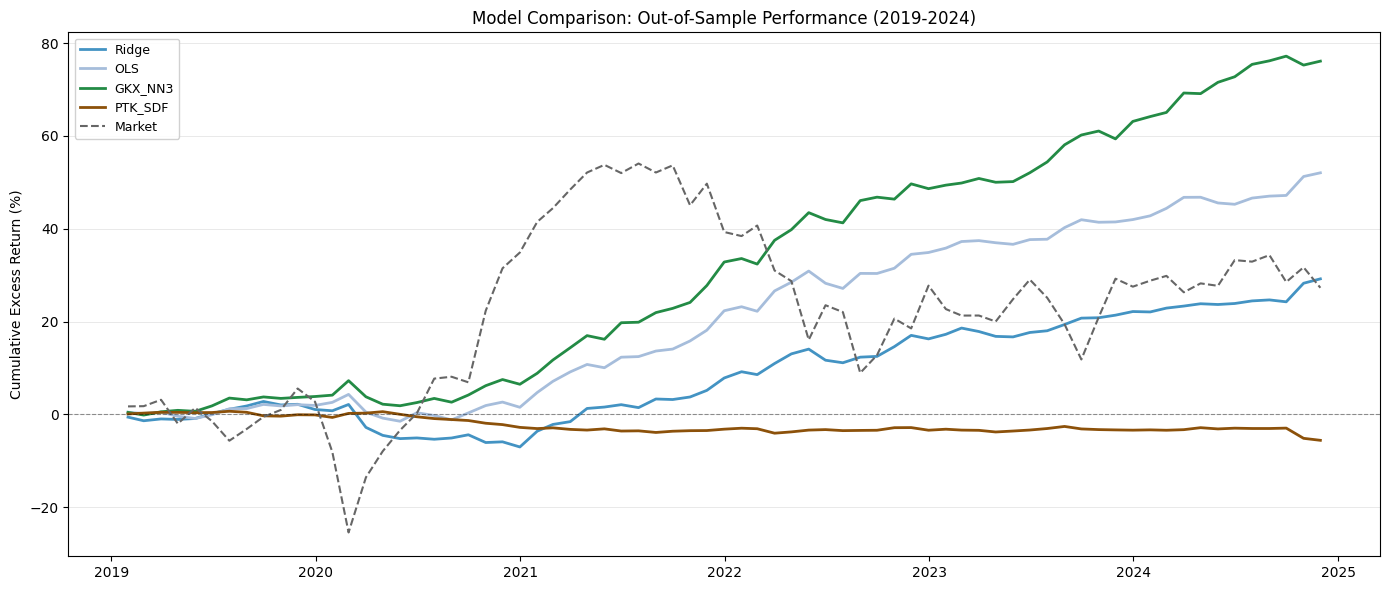

In [34]:
all_returns = pd.DataFrame()

# Add each model's portfolio returns
if 'ridge_pf' in locals() and len(ridge_pf) > 0:
    all_returns['Ridge'] = ridge_pf['Ridge']
if 'ols_pf' in locals() and len(ols_pf) > 0:
    all_returns['OLS'] = ols_pf['OLS']
if 'nn_pf' in locals() and len(nn_pf) > 0:
    all_returns['GKX_NN3'] = nn_pf['NN_GKX']
if 'ptk_dnn_pf' in locals() and len(ptk_dnn_pf) > 0:
    all_returns['DNN_MSRR'] = ptk_dnn_pf['DNN_Predictions']
if 'ptk_pf' in locals() and len(ptk_pf) > 0 and 'PTK_SDF' in ptk_pf.columns:
    all_returns['PTK_SDF'] = ptk_pf['PTK_SDF']
all_returns['Market'] = ridge_pf['Market']  # Equal-weighted market benchmark

# Cumulative returns
cum_returns = (1 + all_returns).cumprod() - 1

fig, ax = plt.subplots(figsize=(14, 6))

colors = {
    'Historical Avg': '#999999',
    'OLS': '#a6bddb',
    'Ridge': '#4393c3',
    'GKX_NN3': '#238b45',
    'DNN_MSRR': '#d6604d',
    'PTK_SDF': '#8c510a',
    'Market': '#666666'
}

for col in cum_returns.columns:
    linestyle = '--' if col == 'Market' else '-'
    lw = 1.5 if col == 'Market' else 2.0
    ax.plot(cum_returns.index, cum_returns[col] * 100,
            color=colors.get(col, '#333333'), 
            linestyle=linestyle, lw=lw,
            label=f"{col}")

ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylabel('Cumulative Excess Return (%)')
ax.set_title('Model Comparison: Out-of-Sample Performance (2019-2024)')
ax.legend(loc='upper left', framealpha=0.9, fontsize=9)
ax.grid(axis='y', lw=0.4, alpha=0.5)
fig.tight_layout()
plt.show()
